> **⚠️ Dataset Requirement:**
> The `listings.csv` file required to run this notebook is hosted on Kaggle.
> Please download it from **https://www.kaggle.com/datasets/ulrikthygepedersen/airbnb-listings** and place it in the same folder as this notebook before executing the cells.

**Dataset Description:**  


The dataset contains 14,124 Airbnb listings in Vienna, Austria, collected from Inside Airbnb in September 2025, with 79 attributes covering hosts, pricing, availability, location, and guest reviews. We selected it because it offers a detailed view of Vienna's short-term rental market, enabling analysis of pricing patterns, neighborhood differences, and guest satisfaction. Its combination of geographic, financial, and review data makes it well-suited for meaningful visualization and exploratory analysis.

### Data Preprocessing & Scientific Filtering

In this section, the raw Airbnb dataset is loaded and subjected to a rigorous cleaning and filtering process. The goal is to ensure that our visual analysis and conclusions are built on valid, active, and strictly comparable data.

Key data processing steps in this cell include:

*   **Feature Selection:** Extracting essential columns related to price, cleanliness score, room type, and necessary control variables.
*   **Data Formatting:** Cleaning the `price` column by stripping text symbols (`$` and `,`) and converting it into a numerical format (float).
*   **Handling Missing Values:** Dropping rows that lack critical information in the neighborhood, price, or cleanliness score columns.
*   **Advanced Scientific Filters:**
    *   Restricting data exclusively to **"Entire home/apt"** to guarantee an apples-to-apples price comparison.
    *   Requiring **at least 10 reviews** to ensure the statistical reliability of the cleanliness scores.
    *   Capping **minimum nights at 30** to exclude long-term and student rentals from the tourist market analysis.
    *   Removing inactive "dead" listings (properties with zero available days in the calendar).
*   **Outlier Removal:** Trimming the top 1% of the most expensive properties (above the 99th percentile) and filtering out invalid zero prices. This prevents severe statistical skewness and dramatically improves the readability of our visualizations.

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the Airbnb dataset - Original
df=pd.read_csv('listings.csv')
print("Original dataset shape:", df.shape)

# 2. Select essential columns PLUS the columns needed for advanced filtering
selected_cols = [
    "neighbourhood_cleansed",
    "price",
    "review_scores_cleanliness",
    "room_type",
    "number_of_reviews",
    "minimum_nights",
    "availability_365"
]
df_airbnb = df[selected_cols].copy()

# 3. Format the 'price' column (remove $ and , then convert to float)
df_airbnb["price"] = (
    df_airbnb["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# 4. Remove missing values (NaN) in the core columns
df_airbnb = df_airbnb.dropna(subset=[
    "neighbourhood_cleansed",
    "price",
    "review_scores_cleanliness"
])

# 5. Apply the ADVANCED SCIENTIFIC FILTERS
df_filtered = df_airbnb[
    (df_airbnb["room_type"] == "Entire home/apt") &  # A.1: Ensure apples-to-apples comparison
    (df_airbnb["number_of_reviews"] >= 10) &         # A.2: Ensure statistical significance of reviews
    (df_airbnb["minimum_nights"] <= 30) &            # A.1 & A.2: Filter out long-term/student rentals
    (df_airbnb["availability_365"] > 0)              # A.1: Remove dead/inactive listings
].copy()

# 6. Remove Price Outliers (keep realistic positive prices under the 99th percentile)
upper_price_limit = df_filtered["price"].quantile(0.99)
df_airbnb_clean = df_filtered[
    (df_filtered["price"] > 0) &
    (df_filtered["price"] <= upper_price_limit)
].copy()

# 7. Final Check
print("Highly-refined dataset shape:", df_airbnb_clean.shape)
df_airbnb_clean.describe()

Original dataset shape: (14123, 79)
Highly-refined dataset shape: (5033, 7)


,price,review_scores_cleanliness,number_of_reviews,minimum_nights,availability_365
count,5033.000000,5033.000000,5033.000000,5033.000000,5033.000000
mean,113.940195,4.739676,88.806080,3.924101,213.944168
std,65.432964,0.222198,103.461108,7.150008,107.704799
min,20.000000,2.860000,10.000000,1.000000,1.000000
25%,71.000000,4.640000,23.000000,1.000000,120.000000
50%,94.000000,4.790000,52.000000,2.000000,240.000000
75%,135.000000,4.900000,114.000000,3.000000,310.000000
max,458.000000,5.000000,1347.000000,30.000000,365.000000


**Hypthesis** A.1:Central Vienna neighborhoods (especially Innere Stadt) have significantly higher median Airbnb prices than peripheral neighborhoods.

### A.1 - The Price Landscape: Neighborhood Price Distribution

To answer our first question—*"Where is it expensive, and where is it cheap?"*—we visualize the distribution of nightly prices across Vienna's neighborhoods using a **Box Plot**.

**Visualization & Design Choices:**
*   **Data Hierarchy (Sorting):** The neighborhoods are sorted dynamically by their median price in descending order. This creates a clear visual ranking, allowing the reader to instantly identify the most and least expensive areas without scanning scattered data.
*   **Pre-attentive Highlighting:** We apply a conditional color encoding (dark red) exclusively to **Innere Stadt** (the historic center). This leverages the Gestalt principle of focal points, immediately drawing the viewer's eye to the most expensive district and establishing a clear baseline to compare against the peripheral neighborhoods (kept in a muted steel blue).
*   **Variance Representation:** The box plot efficiently displays not just the median, but the full spread of prices (minimum to maximum). This visually proves our hypothesis that while central districts are expensive, they still possess a high variance, meaning budget-friendly options exist even in top-tier neighborhoods.

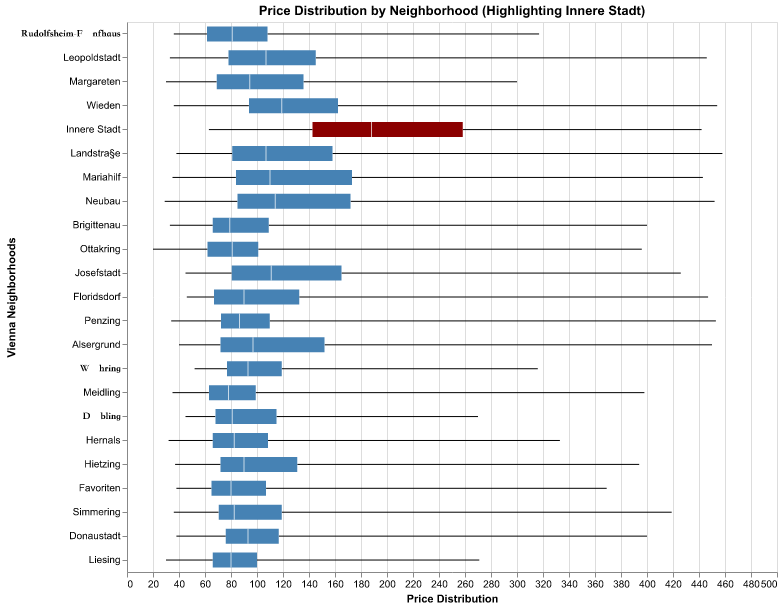

In [ ]:
import altair as alt
alt.data_transformers.disable_max_rows()
alt.renderers.enable('png',scale_factor=2)

# Create a Boxplot to show price distribution across neighborhoods
chart_a1_box = alt.Chart(df_airbnb_clean).mark_boxplot(extent='min-max', size=15).encode(
    x=alt.X('price:Q', title='Price Distribution'),
    y=alt.Y('neighbourhood_cleansed:N',
            sort=alt.EncodingSortField(field='price', op='median', order='descending'),
            title='Vienna Neighborhoods'),
    color=alt.condition(
        alt.datum.neighbourhood_cleansed == 'Innere Stadt',
        alt.value('darkred'),      # Highlight the central district
        alt.value('steelblue')     # Fade out peripheral districts
    )
).properties(
    title='Price Distribution by Neighborhood (Highlighting Innere Stadt)',
    width=650,
    height=550
)

chart_a1_box

This boxplot shows how Airbnb prices differ across Vienna neighborhoods, with Innere Stadt highlighted in red. The chart shows that central districts usually have higher median prices and a larger price range compared to districts farther from the center. Innere Stadt especially stands out with generally more expensive listings. On the other hand, neighborhoods like Favoriten and Simmering mostly contain cheaper listings with less variation in price. The long whiskers and spread in some districts also show that there are a few very expensive listings acting as outliers. Overall, the visualization suggests that the location of a listing has a strong influence on its price.


**Hypthesis A.2:**Higher-priced Airbnb listings deliver a better cleanliness experience, meaning there is a positive correlation between listing price and guest cleanliness score.

###A.2 - Does Price Guarantee Quality? (Price vs. Cleanliness)

**Hypothesis:** Higher-priced Airbnb listings deliver a better cleanliness experience, meaning there is a positive correlation between listing price and guest cleanliness score.

To test this hypothesis, we need to analyze the relationship between two continuous variables across thousands of listings.

**Visualization & Design Choices:**
*   **Density Heatmap over Scatter Plot:** With thousands of data points, a standard scatter plot would suffer from severe overplotting (points stacking on top of each other), creating a massive, unreadable blob. A 2D binned heatmap elegantly solves this by aggregating the data into distinct rectangular grids.
*   **Strategic Binning:** By binning the price into €25 intervals and cleanliness scores into 0.2 intervals, we structure the raw data into meaningful market segments rather than noisy individual points.
*   **Sequential Color Encoding:** We use a sequential color scale (`blues`) to encode the total count of listings per bin. The darkest areas immediately draw the viewer's eye to the highest concentration of the market, clearly revealing whether the bulk of highly-rated apartments are actually the expensive ones.

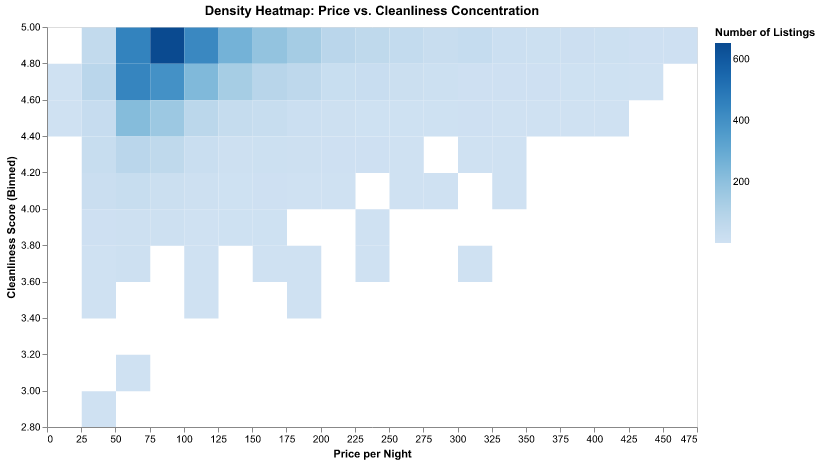

In [ ]:

alt.data_transformers.disable_max_rows()
alt.renderers.enable('png')

chart_a2_heatmap = alt.Chart(df_airbnb_clean).mark_rect().encode(
    # Bin the price into steps of $25
    x=alt.X('price:Q', bin=alt.Bin(step=25), title='Price per Night'),
    # Bin the cleanliness scores
    y=alt.Y('review_scores_cleanliness:Q', bin=alt.Bin(step=0.2), title='Cleanliness Score (Binned)'),
    # Use color to show the concentration of listings
    color=alt.Color('count():Q', scale=alt.Scale(scheme='blues'), title='Number of Listings'),
    tooltip=[
        alt.Tooltip('price:Q', bin=alt.Bin(step=25), title='Price Range'),
        alt.Tooltip('review_scores_cleanliness:Q', bin=alt.Bin(step=0.2), title='Score Range'),
        alt.Tooltip('count():Q', title='Listings Count')
    ]
).properties(
    title='Density Heatmap: Price vs. Cleanliness Concentration',
    width=650,
    height=400
)

chart_a2_heatmap

The heatmap shows the concentration of Airbnb listings based on their price and cleanliness score. Most listings are grouped in the lower and middle price ranges while already having high cleanliness scores between about 4.6 and 5.0. There is a slight increase in cleanliness for more expensive listings, but the relationship is not very strong. Also, there are fewer listings in the high-price ranges, which makes the pattern less reliable there. This matches the weak positive correlation value found earlier (r ≈ 0.14). Overall, the visualization suggests that higher prices do not necessarily mean much better cleanliness scores.

